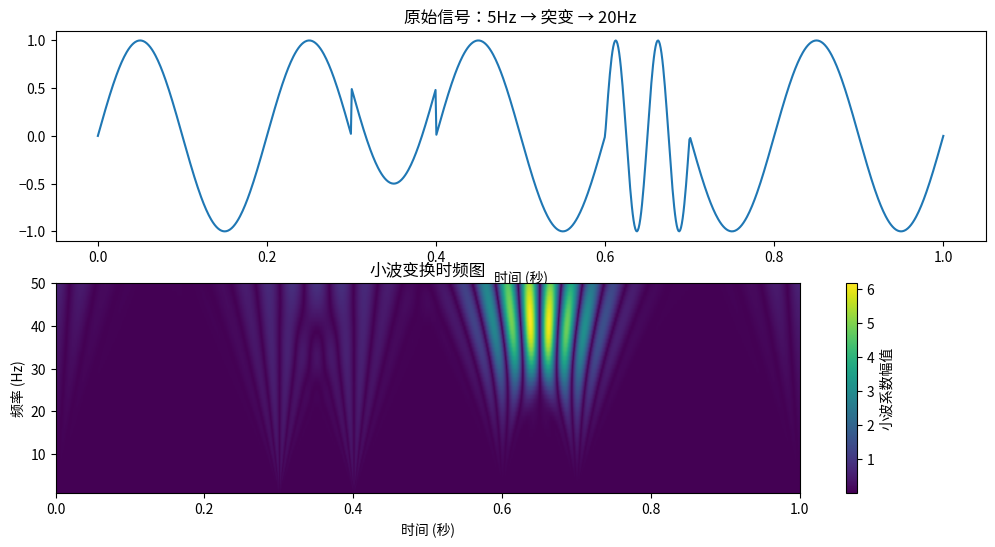

In [1]:
# 小波变换示例：检测突变点
import pywt
import numpy as np
import matplotlib.pyplot as plt

# 生成信号：平稳部分 + 突变 + 非平稳部分
t = np.linspace(0, 1, 1000)
signal = np.sin(2*np.pi*5*t)  # 平稳：5Hz
signal[300:400] += 0.5  # 突变：时刻0.3s
signal[600:700] = np.sin(2*np.pi*20*t[600:700])  # 非平稳：切换到20Hz

# 连续小波变换（使用Morlet小波）
coeffs, freqs = pywt.cwt(signal, np.arange(1, 50), 'morl', 1/1000)

# 可视化
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('原始信号：5Hz → 突变 → 20Hz')
plt.xlabel('时间 (秒)')

plt.subplot(2, 1, 2)
plt.imshow(np.abs(coeffs), aspect='auto', 
           extent=[0, 1, 1, 50], origin='lower')
plt.title('小波变换时频图')
plt.xlabel('时间 (秒)')
plt.ylabel('频率 (Hz)')
plt.colorbar(label='小波系数幅值')
plt.show()

In [4]:
coeffs[0:2, 0:3]

array([[ 3.95079726e-03,  3.94673281e-03,  6.41493751e-05],
       [-2.01777063e-03, -2.01791375e-03,  3.54686295e-03]])